1.  What is Anomaly Detection? Explain its types (point, contextual, and collective anomalies) with examples.
  - Anomaly Detection is the process of finding data points or patterns that are different from normal behavior.
  - Point Anomaly
    - A single data point is abnormal compared to the rest.
    - In credit card transactions, if someone usually spends ₹500-₹2000 but suddenly a transaction of ₹2,00,000 happens → suspicious.
  - Contextual Anomaly
    - A data point is abnormal only in a specific context (time, location, season).
    - 30°C is normal in summer but abnormal in winter.
  - Collective Anomaly
    - A group of data points together is abnormal, even if individual points look normal.
    - A single login at night is fine. But 200 logins within 1 minute → possible attack.

2.  Compare Isolation Forest, DBSCAN, and Local Outlier Factor in terms of their approach and suitable use cases.
  - Isolation Forest randomly splits the data. It should be used when anomaly is far.
  - DBSCAN uses eps and minPts to cluster datapoints. Points that don't belong to cluster are anomaly.
  - Local Outlier Factor uses KNN for clustering. Points that don't belong to cluster are anomaly. It also detects anomaly in local cluster.

3.  What are the key components of a Time Series? Explain each with one example.
  - Trend
    - A long term upward or downward movement.
    - Company sales gradually increasing every year.
  - Seasonality
    - A pattern that repeats at fixed intervals.
    - Ice cream sales higher every summer, lower in winter.
  - Cyclical
    - Up-down movement but not at fixed time gaps.
    - Business growth during boom, fall during recession.
  - Noise
    - Random, unpredictable variation
    - Sudden sales drop due to a strike or weather problem.

4.  Define Stationary in time series. How can you test and transform a non-stationary series into a stationary one?
  - Stationary means statistical property - mean and variance don't change over time.
  - To test either series is stationary or not, we can plot the data or do a statistical test.
  - To transform a non-stationary series into a stationary, we use differncing. yt-(yt - 1).

5.  Differentiate between AR, MA, ARIMA, SARIMA, and SARIMAX models in terms of structure and application.
  - AR (AutoRegressive)
    - Current value depends on past values.
  - MA (Moving Average)
    - Current value depends on past errors (noise).
  - ARIMA (AutoRegressive Integrated Moving Average)
    - Combination of AR + differencing (I) + MA.
  - SARIMA (Seasonal ARIMA)
    - Extension of ARIMA that also models seasonal patterns.
  - SARIMAX (Seasonal ARIMA with eXogenous variables)
    - SARIMA + external factors.

In [73]:
import warnings
warnings.filterwarnings("ignore")

In [74]:
# 6.  Load a time series dataset (e.g., AirPassengers), plot the original series,
# and decompose it into trend, seasonality, and residual components
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

df = pd.read_csv("AirPassengers.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Month        144 non-null    object
 1   #Passengers  144 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 2.4+ KB


In [75]:
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

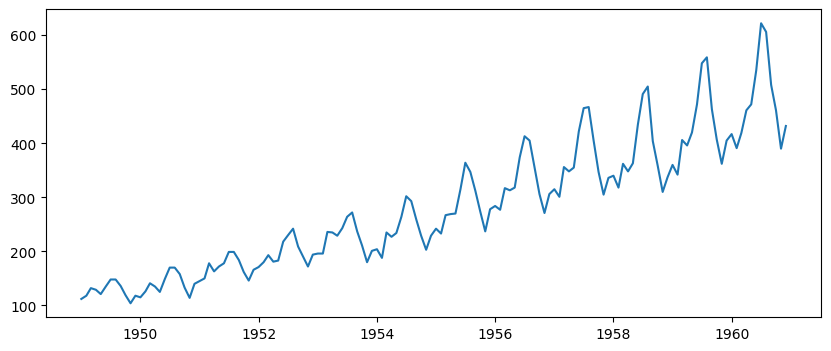

In [76]:
plt.figure(figsize=(10,4))
plt.plot(df)
plt.show()

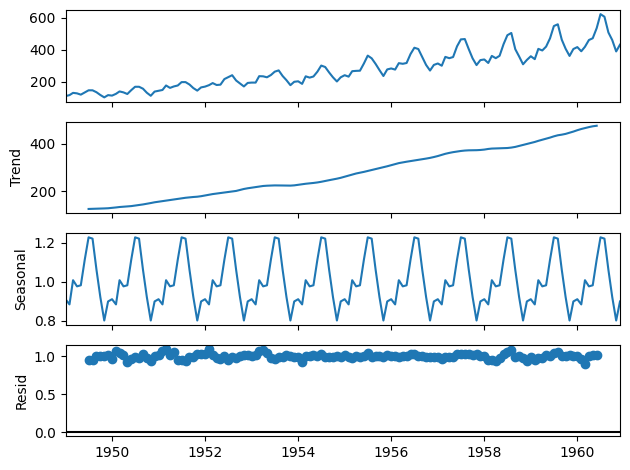

In [77]:
result = seasonal_decompose(df, model="multiplicative", period=12)
result.plot()
plt.show()

In [82]:
# 7.  Apply Isolation Forest on a numerical dataset (e.g., NYC Taxi Fare) to
# detect anomalies. Visualize the anomalies on a 2D scatter plot.
import pandas as pd

df = pd.read_csv("NYC_taxi_fare_data.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6405008 entries, 0 to 6405007
Data columns (total 18 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   VendorID               float64
 1   tpep_pickup_datetime   object 
 2   tpep_dropoff_datetime  object 
 3   passenger_count        float64
 4   trip_distance          float64
 5   RatecodeID             float64
 6   store_and_fwd_flag     object 
 7   PULocationID           int64  
 8   DOLocationID           int64  
 9   payment_type           float64
 10  fare_amount            float64
 11  extra                  float64
 12  mta_tax                float64
 13  tip_amount             float64
 14  tolls_amount           float64
 15  improvement_surcharge  float64
 16  total_amount           float64
 17  congestion_surcharge   float64
dtypes: float64(13), int64(2), object(3)
memory usage: 879.6+ MB


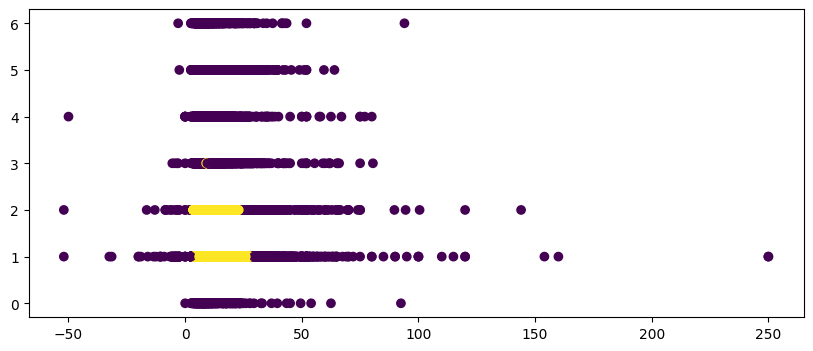

In [86]:
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

X = df.loc[:20000, ["fare_amount", "passenger_count"]].dropna()

model = IsolationForest(random_state=42)
pred = model.fit_predict(X)

plt.figure(figsize=(10,4))
plt.scatter(X["fare_amount"], X["passenger_count"], c=pred)
plt.show()

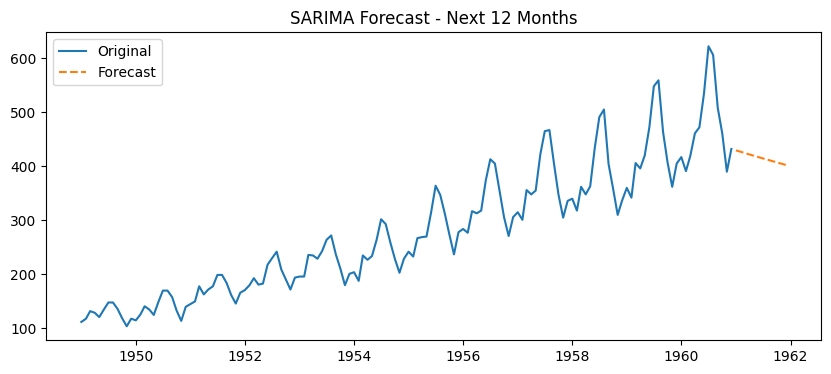

In [79]:
# 8. Train a SARIMA model on the monthly airline passengers dataset.
# Forecast the next 12 months and visualize the results.
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX

df = pd.read_csv("AirPassengers.csv")
df["Month"] = pd.to_datetime(df["Month"])
df.set_index("Month", inplace=True)

model = SARIMAX(df)
model_fit = model.fit(disp=False)

forecast = model_fit.forecast(steps=12)

plt.figure(figsize=(10,4))
plt.plot(df, label="Original")
plt.plot(forecast, label="Forecast", linestyle="--")
plt.title("SARIMA Forecast - Next 12 Months")
plt.legend()
plt.show()

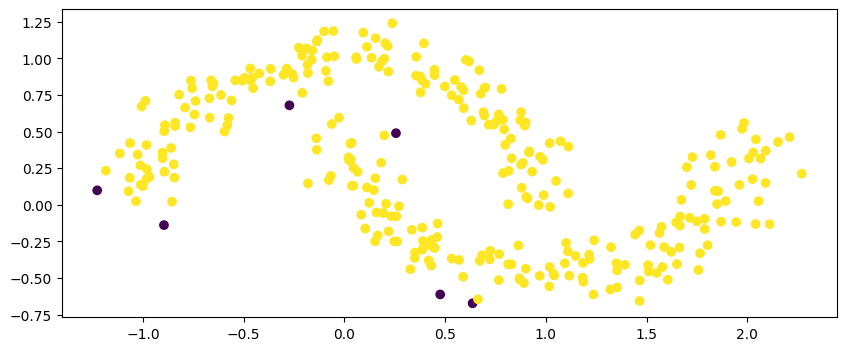

In [80]:
# 9. Apply Local Outlier Factor (LOF) on any numerical dataset to detect
# anomalies and visualize them using matplotlib.
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.neighbors import LocalOutlierFactor

X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

model = LocalOutlierFactor(n_neighbors = 7)
pred = model.fit_predict(X)

plt.figure(figsize=(10, 4))
plt.scatter(X[:,0], X[:,1], c=pred)
plt.show()

In [81]:
# 10.  You are working as a data scientist for a power grid monitoring company.
# Your goal is to forecast energy demand and also detect abnormal spikes or drops in
# real-time consumption data collected every 15 minutes. The dataset includes features
# like timestamp, region, weather conditions, and energy usage.
# Explain your real-time data science workflow:

# ● How would you detect anomalies in this streaming data (Isolation Forest / LOF /
# DBSCAN)?
# ● Which time series model would you use for short-term forecasting (ARIMA /
# SARIMA / SARIMAX)?
# ● How would you validate and monitor the performance over time?
# ● How would this solution help business decisions or operations?

- I will use LOF, as it detects local and global outliers.
- For short-term forecasting, i will use ARIMA.
- I will validate by plotting forecast and original data for every region.
- I will decompose the data to trend, seasonality and noise.
- This solution will help business make decision for power supply release in different regions and weather conditions.